In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kshitizregmi/jobs-and-job-description/job_title_des.csv


In [2]:
!pip install transformers datasets scikit-learn -q



In [3]:
!pip install transformers==4.41.2 peft==0.9.0 sentence-transformers==2.6.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 72.8 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.9/190.9 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.3/163.3 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 103.8 MB/s eta 0:00:0000:01
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uni

In [4]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import pickle
import re

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from datasets import Dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

from torch.nn import CrossEntropyLoss


2026-03-22 12:49:45.076861: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774183785.252310      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774183785.302819      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774183785.719822      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774183785.719859      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774183785.719862      55 computation_placer.cc:177] computation placer alr

In [5]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [6]:
df = pd.read_csv("/kaggle/input/datasets/kshitizregmi/jobs-and-job-description/job_title_des.csv")

In [7]:
df.head(10)

,Unnamed: 0,Job Title,Job Description
0,0,Flutter Developer,We are looking for hire experts flutter develo...
1,1,Django Developer,PYTHON/DJANGO (Developer/Lead) - Job Code(PDJ ...
2,2,Machine Learning,"Data Scientist (Contractor)\n\nBangalore, IN\n..."
3,3,iOS Developer,JOB DESCRIPTION:\n\nStrong framework outside o...
4,4,Full Stack Developer,job responsibility full stack engineer – react...
5,5,Java Developer,Software Developer - Integration*\nImmediate O...
6,6,Full Stack Developer,senior full stack developer \- 1800026h cwt lo...
7,7,JavaScript Developer,"Job Description:\n\nReactJS + NodeJs, Azure Fu..."
8,8,DevOps Engineer,Main Responsibilities and Deliverables:\nManag...
9,9,Software Engineer,"Overview\n\n\nBased in Silicon Valley, Tintri ..."


In [8]:
df = df.dropna()

In [9]:
df["text"] = df["Job Title"] + " " + df["Job Description"]



In [10]:
def assign_label(text):
    text = text.lower()
    if "machine learning" in text or "ai" in text or "deep learning" in text:
        return "AI"
    elif "data" in text or "sql" in text or "analytics" in text:
        return "Data"
    elif "react" in text or "developer" in text or "frontend" in text:
        return "Web"
    else:
        return "Other"

df["label"] = df["text"].apply(assign_label)
label_map = {"AI":0, "Data":1, "Web":2, "Other":3}
df["label"] = df["label"].map(label_map)


In [11]:
def clean_text(text):
    
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["text"] = df["text"].apply(clean_text)

In [12]:
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)

In [13]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)
class_weights = torch.tensor(class_weights, dtype=torch.float)


In [14]:
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

In [15]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=256)

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])
val_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

Map:   0%|          | 0/456 [00:00<?, ? examples/s]

In [16]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=4
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [17]:
from torch.nn import CrossEntropyLoss
from transformers import Trainer

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        
        device = next(model.parameters()).device
        loss_fct = CrossEntropyLoss(weight=class_weights.to(device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [18]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")
    return {"accuracy": acc, "f1": f1}


In [19]:
training_args = TrainingArguments(
    output_dir="/kaggle/working/results",
    learning_rate=5e-5,               
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy= "steps",
    logging_steps=100,
    save_total_limit=1,
    logging_dir="/kaggle/working/logs",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    save_safetensors=False,
    warmup_steps=500,                 
    gradient_accumulation_steps=2
    
)






In [20]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]  
)

In [21]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,1.334886,0.771930,0.730705
2,1.322700,1.135759,0.660088,0.674588
3,1.322700,1.030345,0.425439,0.473546
4,1.046700,0.865754,0.750000,0.769227
5,1.046700,0.603021,0.673246,0.696763
6,0.661900,0.684859,0.491228,0.512215
7,0.661900,0.683662,0.855263,0.846657
8,0.426900,0.555532,0.828947,0.839374
9,0.179000,1.080863,0.881579,0.873815
10,0.179000,0.762652,0.868421,0.870956


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

TrainOutput(global_step=570, training_loss=0.645188233726903, metrics={'train_runtime': 316.9984, 'train_samples_per_second': 57.445, 'train_steps_per_second': 1.798, 'total_flos': 1206158683484160.0, 'train_loss': 0.645188233726903, 'epoch': 10.0})

In [22]:
log_history = trainer.state.log_history
print("Epoch\tTrain Loss\tVal Loss\tAccuracy\tF1")
for log in log_history:
    if "epoch" in log:
        train_loss = log.get("loss", None)
        val_loss = log.get("eval_loss", None)
        acc = log.get("eval_accuracy", None)
        f1 = log.get("eval_f1", None)
        print(f"{log['epoch']:.1f}\t{train_loss}\t{val_loss}\t{acc}\t{f1}")

Epoch	Train Loss	Val Loss	Accuracy	F1
1.0	None	1.3348861932754517	0.7719298245614035	0.7307047368587131
1.8	1.3227	None	None	None
2.0	None	1.1357593536376953	0.6600877192982456	0.6745882374381437
3.0	None	1.0303446054458618	0.42543859649122806	0.47354579027365173
3.5	1.0467	None	None	None
4.0	None	0.8657535910606384	0.75	0.7692274291543573
5.0	None	0.6030207276344299	0.6732456140350878	0.6967632898034559
5.3	0.6619	None	None	None
6.0	None	0.6848589777946472	0.49122807017543857	0.5122151343490787
7.0	None	0.6836618185043335	0.8552631578947368	0.8466566098216556
7.0	0.4269	None	None	None
8.0	None	0.5555315613746643	0.8289473684210527	0.8393740613642645
8.8	0.179	None	None	None
9.0	None	1.0808625221252441	0.881578947368421	0.8738154836728373
10.0	None	0.7626524567604065	0.868421052631579	0.8709561130239931
10.0	None	None	None	None


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


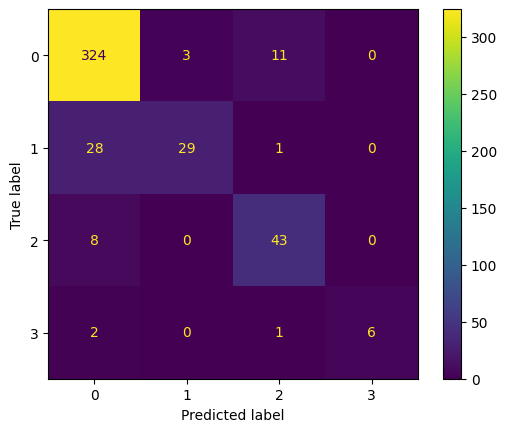

In [23]:
preds_output = trainer.predict(val_dataset)
y_true = preds_output.label_ids
y_pred = np.argmax(preds_output.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

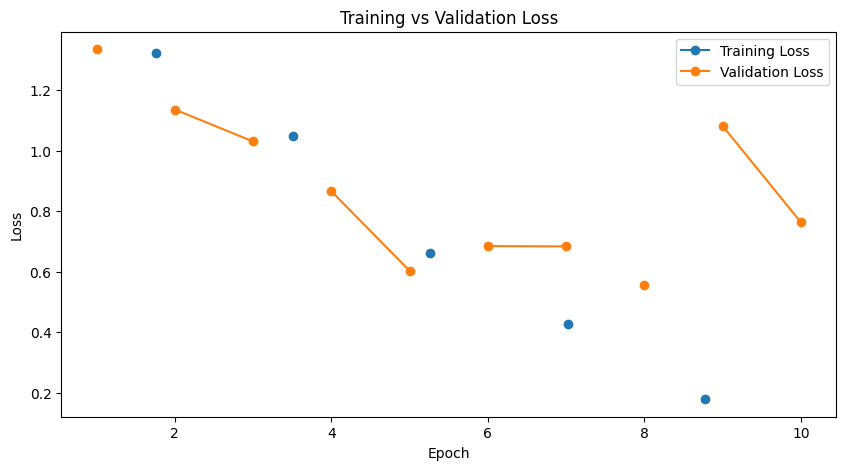

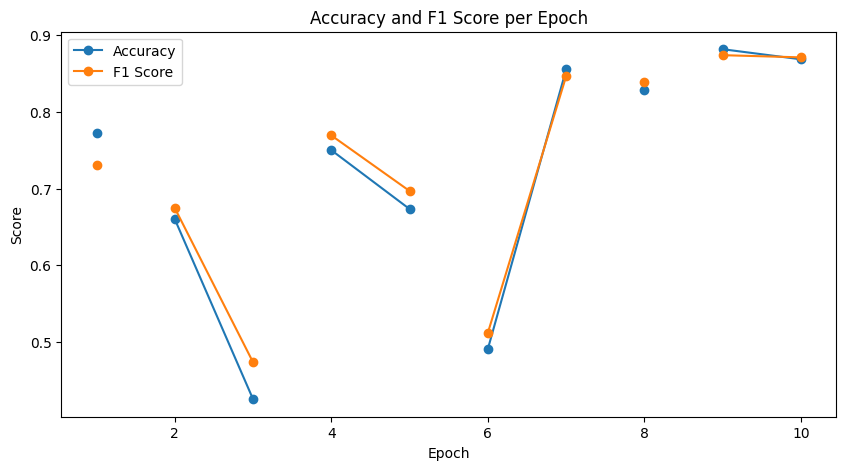

In [24]:

import matplotlib.pyplot as plt


epochs = []
train_losses = []
val_losses = []
accuracies = []
f1_scores = []

for log in trainer.state.log_history:
    if "epoch" in log:
        epochs.append(log["epoch"])
        train_losses.append(log.get("loss", None))
        val_losses.append(log.get("eval_loss", None))
        accuracies.append(log.get("eval_accuracy", None))
        f1_scores.append(log.get("eval_f1", None))


plt.figure(figsize=(10,5))
plt.plot(epochs, train_losses, label="Training Loss", marker='o')
plt.plot(epochs, val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


plt.figure(figsize=(10,5))
plt.plot(epochs, accuracies, label="Accuracy", marker='o')
plt.plot(epochs, f1_scores, label="F1 Score", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Accuracy and F1 Score per Epoch")
plt.legend()
plt.show()

In [26]:
model.save_pretrained("/kaggle/working/model")
tokenizer.save_pretrained("/kaggle/working/model")

with open("/kaggle/working/model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved (transformer + pkl)")

Model saved (transformer + pkl)
